In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel('/workspaces/proyecto-coches/data/raw/car_prices_dataset.xlsx')

In [4]:
data.head()

,year,mark,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   mark          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [6]:
data.isnull().sum()

year                0
mark            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [7]:
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472325 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          472325 non-null  int64  
 1   mark          472325 non-null  object 
 2   model         472325 non-null  object 
 3   trim          472325 non-null  object 
 4   body          472325 non-null  object 
 5   transmission  472325 non-null  object 
 6   vin           472325 non-null  object 
 7   state         472325 non-null  object 
 8   condition     472325 non-null  float64
 9   odometer      472325 non-null  float64
 10  color         472325 non-null  object 
 11  interior      472325 non-null  object 
 12  seller        472325 non-null  object 
 13  mmr           472325 non-null  float64
 14  sellingprice  472325 non-null  float64
 15  saledate      472325 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 61.3+ MB


In [8]:
data.nunique()

year                26
mark                53
model              768
trim              1494
body                85
transmission         2
vin             465768
state               34
condition           41
odometer        160427
color               20
interior            17
seller           11923
mmr               1099
sellingprice      1806
saledate          3609
dtype: int64

In [9]:
data.head(1)

,year,mark,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)


In [10]:
data = data[['mark', 'model', 'year', 'body', 'transmission', 'odometer', 'condition', 'color', 'interior', 'seller', 'state', 'saledate', 'mmr', 'sellingprice']]
data.head(1)

,mark,model,year,body,transmission,odometer,condition,color,interior,seller,state,saledate,mmr,sellingprice
0,Kia,Sorento,2015,SUV,automatic,16639.0,5.0,white,black,kia motors america inc,ca,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),20500.0,21500.0


In [11]:
data['saledate'] = pd.to_datetime(data['saledate'], errors='coerce', utc=True)

# Formatear solo con día, mes y año
data['saledate'] = data['saledate'].dt.strftime('%d-%m-%Y')

data.head(1)

/tmp/ipykernel_7922/3574406828.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['saledate'] = pd.to_datetime(data['saledate'], errors='coerce', utc=True)


,mark,model,year,body,transmission,odometer,condition,color,interior,seller,state,saledate,mmr,sellingprice
0,Kia,Sorento,2015,SUV,automatic,16639.0,5.0,white,black,kia motors america inc,ca,16-12-2014,20500.0,21500.0


In [14]:
# ...existing code...
num_duplicados = data.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicados}")
# ...existing code...

Número de filas duplicadas: 0


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472325 entries, 0 to 558836
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   mark          472325 non-null  object 
 1   model         472325 non-null  object 
 2   year          472325 non-null  int64  
 3   body          472325 non-null  object 
 4   transmission  472325 non-null  object 
 5   odometer      472325 non-null  float64
 6   condition     472325 non-null  float64
 7   color         472325 non-null  object 
 8   interior      472325 non-null  object 
 9   seller        472325 non-null  object 
 10  state         472325 non-null  object 
 11  saledate      472325 non-null  object 
 12  mmr           472325 non-null  float64
 13  sellingprice  472325 non-null  float64
dtypes: float64(4), int64(1), object(9)
memory usage: 54.1+ MB


In [16]:
data.drop_duplicates(inplace=True)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472325 entries, 0 to 558836
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   mark          472325 non-null  object 
 1   model         472325 non-null  object 
 2   year          472325 non-null  int64  
 3   body          472325 non-null  object 
 4   transmission  472325 non-null  object 
 5   odometer      472325 non-null  float64
 6   condition     472325 non-null  float64
 7   color         472325 non-null  object 
 8   interior      472325 non-null  object 
 9   seller        472325 non-null  object 
 10  state         472325 non-null  object 
 11  saledate      472325 non-null  object 
 12  mmr           472325 non-null  float64
 13  sellingprice  472325 non-null  float64
dtypes: float64(4), int64(1), object(9)
memory usage: 54.1+ MB


## No duplicates

In [18]:
data.to_excel('/workspaces/proyecto-coches/data/processed/car_prices_data.xlsx', index=False)

In [19]:
data.columns

Index(['mark', 'model', 'year', 'body', 'transmission', 'odometer',
       'condition', 'color', 'interior', 'seller', 'state', 'saledate', 'mmr',
       'sellingprice'],
      dtype='object')

In [36]:
data['body'].value_counts()

body
Sedan              174647
SUV                100347
sedan               36651
suv                 20621
Hatchback           19351
                    ...  
g37 convertible         3
CTS-V Wagon             1
Ram Van                 1
cab plus 4              1
cts wagon               1
Name: count, Length: 85, dtype: int64

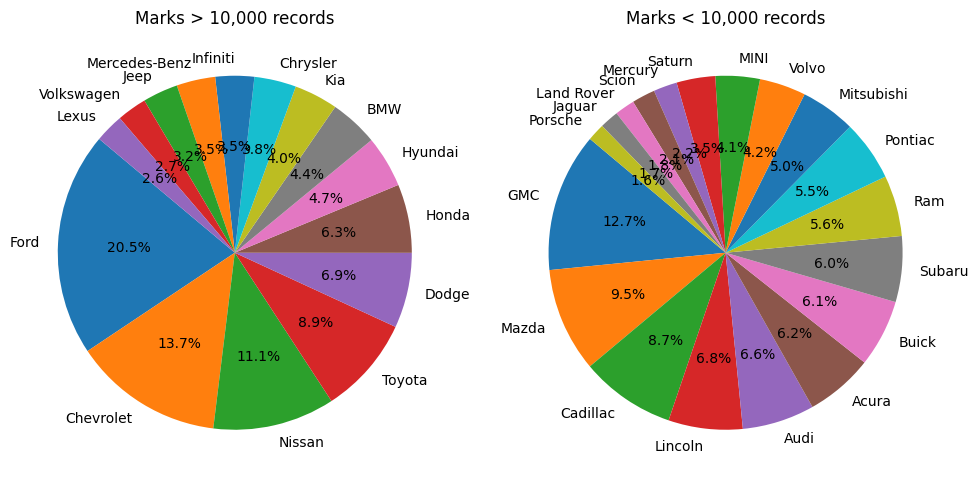

In [33]:
mark_counts = data['mark'].value_counts()

# Filtrar las marcas con más de 10,000 registros
mark_counts_filtered_over_10k = mark_counts[mark_counts > 10000]
mark_counts_filtered_less_10k = mark_counts[(mark_counts < 10000) & (mark_counts > 1000)]

# Gráfico para marcas con más de 10,000 registros
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)  # Primer gráfico
plt.pie(mark_counts_filtered_over_10k, labels=mark_counts_filtered_over_10k.index, autopct='%1.1f%%', startangle=140)
plt.title('Marks > 10,000 records')

# Gráfico para marcas con menos de 10,000 registros
plt.subplot(1, 2, 2)  # Segundo gráfico
plt.pie(mark_counts_filtered_less_10k, labels=mark_counts_filtered_less_10k.index, autopct='%1.1f%%', startangle=140)
plt.title('Marks < 10,000 records')

plt.tight_layout()  # Ajustar el diseño
plt.show()

In [40]:
data['body'] = data['body'].replace('Sedan', 'sedan')
data['body'] = data['body'].replace('Suv', 'suv')

data['body'].value_counts()


body
sedan              211298
suv                120968
Hatchback           19351
Minivan             18305
Coupe               13121
                    ...  
g37 convertible         3
CTS-V Wagon             1
Ram Van                 1
cab plus 4              1
cts wagon               1
Name: count, Length: 83, dtype: int64

In [55]:
data_body = data['body'].value_counts().to_frame().reset_index()
data_body.columns = ['body', 'count']
data_body.to_excel('/workspaces/proyecto-coches/data/processed/body_counts.xlsx', index=False)
